In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import re
from dask.distributed import Client
# qsub -I -q normal -P er8 -l walltime=2:00:00,ncpus=24,mem=120GB,jobfs=100MB,storage=gdata/xp65+gdata/er8+gdata/ob53+gdata/rt52+gdata/rv74+gdata/su28
root_dir = '/home/548/cd3022/repos/hot-cloudy' # change for your own directory

In [2]:
# client = Client(
#     n_workers=24,
#     threads_per_worker=1
# )
# client

In [9]:
ct

<xarray.DataArray 'ct' (time: 500681, lat: 1666, lon: 2271)> Size: 8TB
dask.array<open_dataset-ct, shape=(500681, 1666, 2271), dtype=float32, chunksize=(20, 1666, 2271), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 4MB 2015-07-02T03:50:00 ... 2025-03-31...
  * lat          (lat) float64 13kB 19.37 19.32 19.27 ... -64.8 -64.85 -64.9
  * lon          (lon) float64 18kB 65.06 65.11 65.16 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    ancillary_variables:  ct_status_flag ct_conditions ct_quality ct_pal
    comment:              1:  Cloud-free land; 2:  Cloud-free sea; 3:  Snow o...
    flag_meanings:        Cloud-free_land Cloud-free_sea Snow_over_land Sea_i...
    flag_values:          [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
    long_name:            NWC GEO CT Cloud Type
    valid_range:          [1, 15]

In [3]:
# PREPARE DATA
ds = xr.open_zarr("/g/data/su28/himawari-ahi/cloud/ct/aus_regional_domain/S_NWC_CT_HIMA08_HIMA-N-NR.zarr")
ct = ds.ct

ct.rio.set_spatial_dims(
    x_dim='lon',
    y_dim='lat',
    inplace=True
)

ct.rio.write_crs('EPSG:4326', inplace=True)

gdf = gpd.read_file('/g/data/er8/users/cd3022/data/boundary_files/GCCSA/GCCSA_2021_AUST_GDA2020.shp')


df = pd.read_csv(root_dir + '/hot_cloudy_2015_2024/event_dates_csi0p5_thourly90_counts.csv')
df_null = pd.read_csv(root_dir + '/hot_cloudy_2015_2024/null_event_dates_csi0p5_thourly90_nhours7.csv')

regions = [
    'BRI',
    'SYD',
    'MEL',
    'ADE'
]

# ct_aggs = {
#     'cloud-free': [1, 2, 3, 4],
#     'low': [5, 6],
#     'mid': [7],
#     'high-opaque': [8, 9],
#     'high-semitransparent': [10, 11, 12, 13, 14],
# }

ct_aggs = {
    'Cloud Free': [1, 2, 3, 4],
    'Low': [5, 6],
    'Medium': [7, 10, 14],
    'High': [8, 9],
    'High Thin': [11, 12, 13],
}

categories = {int(num) + 1: desc for num, desc in enumerate(ct_aggs.keys())}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [4]:
x = df[df['region'].str.contains('GMEL')].reset_index().time
y = df_null[df_null['region'].str.contains('GMEL')].reset_index().time

In [5]:
################################################################################################################################
################################################################################################################################
################################################################################################################################
'''
NEED TO CHANGE ALL DAYS TO NO EVENT DAYS
'''
################################################################################################################################
################################################################################################################################
################################################################################################################################

def count_ct():
    CLOUD_TYPES = ct_aggs.keys()
    
    def empty_cloud_dict():
        return {k: [] for k in CLOUD_TYPES}
    
    hot_cloudy = empty_cloud_dict()
    hot_sunny = empty_cloud_dict()
    no_event  = empty_cloud_dict()
    
    for idx, reg in enumerate(regions):
        
        df_reg = df[df['region'].str.contains(reg)].reset_index()
        df_reg_null = df_null[df_null['region'].str.contains(reg)].reset_index()
        dates_reg = df_reg.time
        dates_reg_null = df_reg_null.time
        
        gdf_reg = gdf[gdf['GCC_CODE21'].str.contains(reg)]
        
        # isolate region to reduce ds size
        reg_ct = ct.rio.clip(
            gdf_reg.geometry.apply(mapping),
            gdf_reg.crs,
            drop=True
        )
        
        # CLOUD TYPE DURING EVENTS
        dates_ct = []
        for date in dates_reg:
            cloud_types = reg_ct.sel(time=slice(date + 'T0000', date + 'T0650'))
            dates_ct.append(cloud_types)
        
        dates_ct = xr.concat(dates_ct, dim='time')
        
        # SAME BUT DURING NULL EVENTS
        dates_ct_null = []
        for date in dates_reg_null:
            cloud_types = reg_ct.sel(time=slice(date + 'T0000', date + 'T0650'))
            dates_ct_null.append(cloud_types)
        
        dates_ct_null = xr.concat(dates_ct_null, dim='time')

        # NO EVENT DAYS
        any_event_dates = pd.concat([dates_reg, dates_reg_null])
        dates_ct_no_event = reg_ct.sel(time=~reg_ct.time.isin(any_event_dates.values))

        
        for i, agg in enumerate(CLOUD_TYPES):
            ct_codes = ct_aggs[agg]
            dates_ct = xr.where(dates_ct.isin(ct_codes), i + 1, dates_ct)
            dates_ct_null = xr.where(dates_ct_null.isin(ct_codes), i + 1, dates_ct_null)
            dates_ct_no_event = xr.where(dates_ct_no_event.isin(ct_codes), i + 1, dates_ct_no_event)
        
        bins = np.arange(1, 7) - 0.5
        
        counts_ct, _ = np.histogram(dates_ct.values.flatten(), bins=bins)
        counts_null, _ = np.histogram(dates_ct_null.values.flatten(), bins=bins)
        counts_no_event, _ = np.histogram(dates_ct_no_event.values.flatten(), bins=bins)
        
        # normalise to density
        counts_ct = counts_ct / counts_ct.sum()
        counts_null = counts_null / counts_null.sum()
        counts_no_event = counts_no_event / counts_no_event.sum()
    
        for i, agg in enumerate(CLOUD_TYPES):
            hot_cloudy[agg].append(counts_ct[i])
            hot_sunny[agg].append(counts_null[i])
            no_event[agg].append(counts_no_event[i])


    hot_cloudy_df = pd.DataFrame(
        hot_cloudy,
        index=pd.Index(regions, name="region")
    )
    hot_sunny_df = pd.DataFrame(
        hot_sunny,
        index=pd.Index(regions, name="region")
    )
    no_event_df = pd.DataFrame(
        no_event,
        index=pd.Index(regions, name="region")
    )
    
    hot_cloudy_df.to_csv('/home/548/cd3022/repos/hot-cloudy/hot_cloudy_2015_2024/cloud_types_hot-cloudy.csv')
    hot_sunny_df.to_csv('/home/548/cd3022/repos/hot-cloudy/hot_cloudy_2015_2024/cloud_types_hot-sunny.csv')
    no_event_df.to_csv('/home/548/cd3022/repos/hot-cloudy/hot_cloudy_2015_2024/cloud_types_no-event.csv')
    return

In [6]:
compute = True
if compute:
    count_ct()

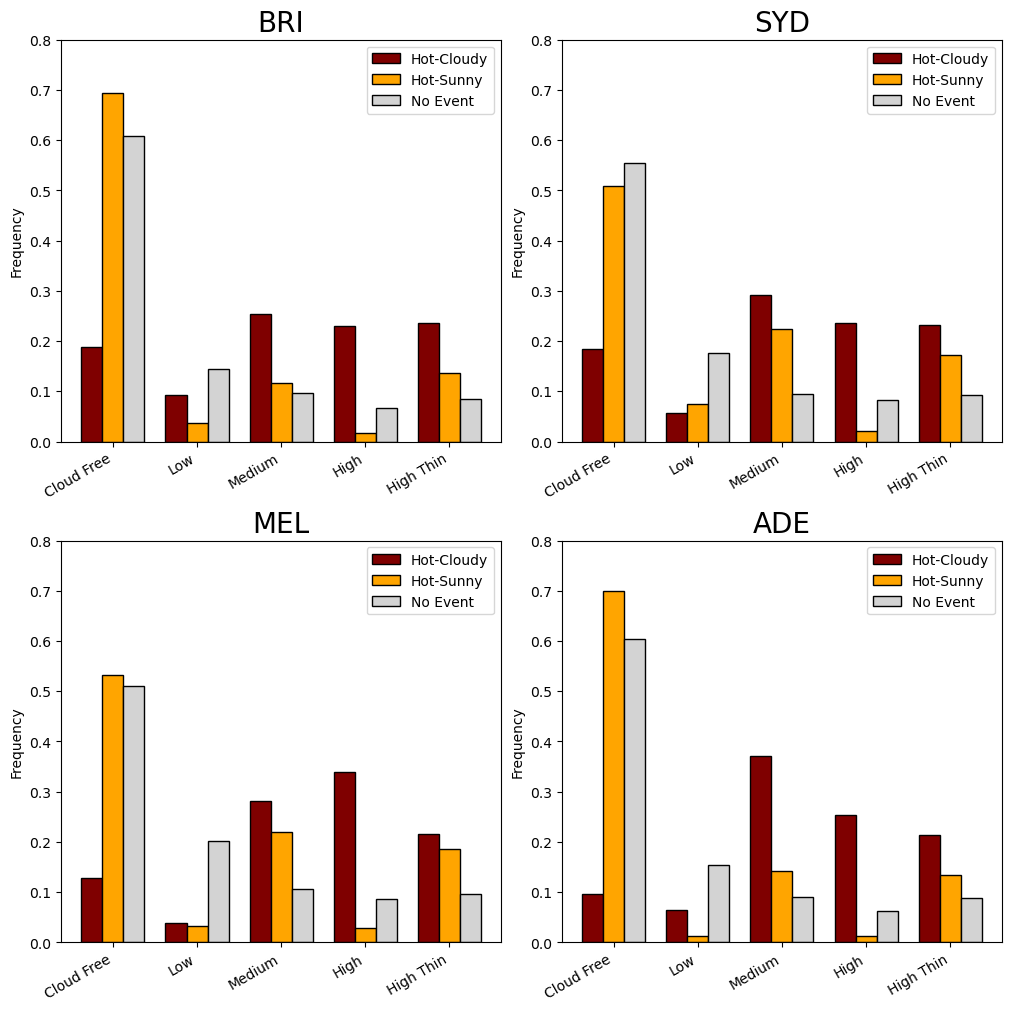

In [7]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10), constrained_layout=True)
ax = ax.flatten()
width = 0.25

bins = np.arange(1, 7) - 0.5
bin_centers = np.arange(1, 6)

hot_cloudy_df = pd.read_csv('/home/548/cd3022/repos/hot-cloudy/hot_cloudy_2015_2024/cloud_types_hot-cloudy.csv', index_col='region')
hot_sunny_df = pd.read_csv('/home/548/cd3022/repos/hot-cloudy/hot_cloudy_2015_2024/cloud_types_hot-sunny.csv', index_col='region')
no_event_df = pd.read_csv('/home/548/cd3022/repos/hot-cloudy/hot_cloudy_2015_2024/cloud_types_no-event.csv', index_col='region')
for idx, reg in enumerate(regions):
   
    cloudy_counts = hot_cloudy_df.loc[reg].values
    sunny_counts = hot_sunny_df.loc[reg].values
    none_counts = no_event_df.loc[reg].values
    
    ax[idx].bar(
        bin_centers - width,
        cloudy_counts,
        width=width,
        edgecolor="black",
        label="Hot-Cloudy",
        color='#7f0000',
    )
    ax[idx].bar(
        bin_centers,
        sunny_counts,
        width=width,
        edgecolor="black",
        label="Hot-Sunny",
        color='#FFA500'
    )
    ax[idx].bar(
        bin_centers + width,
        none_counts,
        width=width,
        edgecolor="black",
        label="No Event",
        color='#D3D3D3'
    )
    
    ax[idx].set_xticks(bin_centers)
    ax[idx].set_xticklabels(list(categories.values()), rotation=30, ha="right")

    ax[idx].set_ylim(0, 0.8)
    
    ax[idx].set_ylabel("Frequency")
    ax[idx].set_title(reg, fontsize=20)
    ax[idx].legend()
    plt.savefig(f'{root_dir}/figs/ct_histogram.png', dpi=600)